In [1]:
import pandas as p
from sklearn.preprocessing import StandardScaler

feature_cols = [
   "RELEVANCE_FEAT",
   "total_words",
   "total_sentences",
   "avg_sentence_len",
   "unique_word_ratio",
   "pos_word_ratio",
   "SPELLING_FEAT"
]

DIR_DATA = "./dataset/.ignore"
df_train = p.read_csv("{}/df_train_final.csv".format(DIR_DATA))
df_dev = p.read_csv("{}/df_dev_final.csv".format(DIR_DATA))

X_train = df_train[feature_cols].values
y_train = df_train['LABEL'].values

X_dev = df_dev[feature_cols].values
y_dev = df_dev['LABEL'].values

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled = scaler.transform(X_dev)


print(f"Feat count: {X_train.shape[1]}")
print(f"Train data length: {len(X_train)}")

Feat count: 7
Train data length: 573


In [2]:
from model_building import build_model

model = build_model(input_dim=X_train.shape[1])
model.summary()

/Users/rivaalms/Developer/widyatama/aes2/aes/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/rivaalms/Developer/widyatama/aes2/aes/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,393 (44.50 KB)

 Trainable params: 11,393 (44.50 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

print("\n-- Training Model --")
history = model.fit(
   X_train_scaled, y_train,
   validation_data=(X_dev_scaled, y_dev),
   epochs=500,
   batch_size=32,
   callbacks=[early_stop],
   verbose=1
)


-- Training Model --
Epoch 1/500
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3643 - loss: 0.7554 - val_accuracy: 0.3725 - val_loss: 0.7150
Epoch 2/500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3978 - loss: 0.7308 - val_accuracy: 0.3813 - val_loss: 0.7039
Epoch 3/500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3549 - loss: 0.7339 - val_accuracy: 0.4401 - val_loss: 0.6952
Epoch 4/500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4359 - loss: 0.7108 - val_accuracy: 0.5338 - val_loss: 0.6882
Epoch 5/500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4169 - loss: 0.7066 - val_accuracy: 0.5882 - val_loss: 0.6824
Epoch 6/500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4837 - loss: 0.6929 - val_accuracy: 0.6209 - val_loss: 0.6769
Epoch 7/500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5517 - loss: 0.6889 - val_accuracy: 0.6253 - val_loss: 0.6715
Epoch 8/500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5483 - loss: 0.6780 - va

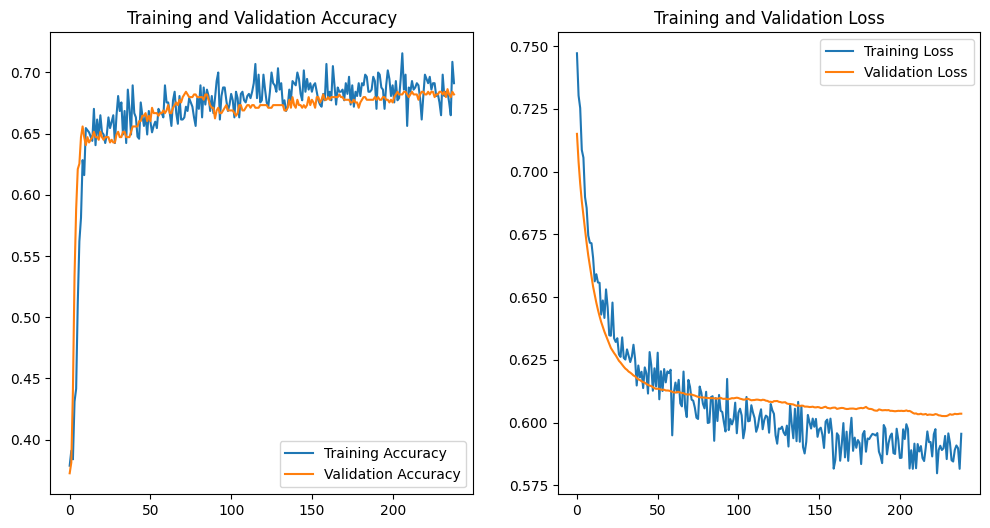

In [4]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

In [ ]:
import pickle

MODEL_DIR = "./models"
model.save("{}/aes_model.keras".format(MODEL_DIR))
print("Model saved")

scaler_path = "./pickle/scaler.pkl"

with open(scaler_path, "wb") as f:
   pickle.dump(scaler, f)

print(f"Scaler saved to: {scaler_path}")

Model saved
Scaler saved to: ./pickle/scaler.pkl
